# Summarize the 

Process the result of grid search inversion and summarize the source properties of gouge-patch source.

2023.10.23 Kurama Okubo

- 2024.02.09 update for master plot: update M0hat and M0
- 2024.10.31 update for the merged catalog.

NOTE: We use the VR from the P window. The result of VR for PS is identical to the P because we set `alpha_p=1.0`, `alpha_s=0.0` in the grid search.

- 2025.03.17 update for master analysis. **NOTE** This is the preliminary processing to estimate the source parameter, but NOT used for the scaling analysis. See `ComputeScaling` for the main analysis to evaluate the source parameters of GP event.

- 2025.12.3 update to process the GP events generated from P5 for revision.

In [1]:
import os
import obspy
from obspy import read, Stream, Trace
from scipy import signal
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
%matplotlib inline
import glob
from glob import glob
import numpy as np
import pandas as pd
import datetime
from datetime import timedelta
from tqdm import tqdm
import warnings
import time

from multiprocessing import Pool, cpu_count
from obspy.signal.cross_correlation import correlate, xcorr_max

from itertools import combinations

from scipy.spatial.distance import euclidean, correlation

%load_ext autoreload
%autoreload 2

from AEevents_Gridsearch_PS_func import *
from AEevents_plot_func import *

plt.rcParams["font.family"] = 'Arial'
# plt.rcParams["font.sans-serif"] = "DejaVu Sans, Arial, Helvetica, Lucida Grande, Verdana, Geneva, Lucid, Avant Garde, sans-serif"
plt.rcParams["font.size"] = 12
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 4.75
plt.rcParams["xtick.major.width"] = 0.75
plt.rcParams["xtick.minor.size"] = 3
plt.rcParams["xtick.minor.width"] = 0.4
plt.rcParams["xtick.minor.visible"] = True

plt.rcParams["ytick.direction"] = "in"
plt.rcParams["ytick.major.size"] = 4.75
plt.rcParams["ytick.major.width"] = 0.75
plt.rcParams["ytick.minor.size"] = 3
plt.rcParams["ytick.minor.width"] = 0.4
plt.rcParams["ytick.minor.visible"] = True

plt.rcParams["savefig.transparent"] = True

plt.rcParams['axes.linewidth'] = 0.75
os.environ['TZ'] = 'GMT' # change time zone to avoid confusion in unix_tvec conversion
UTCDateTime.DEFAULT_PRECISION = 8 # increase the time precision


In [2]:
# datadir
data_inputdir = "../data/07_DATA_MTinversion"

figdir = "../figure/08_summary_VR"
if not os.path.exists(figdir):
    os.makedirs(figdir)

In [4]:
expr_id = 87
# event_ids = [3, 16, 17, 30, 51, 52, 58, 61, 77, 91, 99, 106, 21, 32, 35, 67, 90, 97, 104, \
#             24, 36, 41, 43, 46, 70, 71, 81 ,82] # Ordinary, x=1750, rupturetype all (1, 2, and 3) # excluded 37 due to low S/N

event_ids = [17,  23,  29,  33,  36,  42,  65,  80,  90,  93, 103, 106, 107, 108, 114, 115] # Ordinary, x=2750, exclude 56, 57, signal too large; 123 low S/N

datacase_list = ["fb03-{:03d}__{:04d}".format(expr_id, x) for x in event_ids]



In [5]:
balldrop_model=4 # 2 for the model only with SiTj, 4 for the SiTjbeta

df_VR_all = pd.read_csv(data_inputdir+"/MTinv_gridsearch_{}_balldropmodel{}.csv".format(datacase_list[11], balldrop_model), index_col=0)

In [6]:
df_VR_all

,Mw,M0hat,M0,rake,TR,VR_P,VR_S,VR_PS,VR_sensors,Nsensor
0,-8.070000,0.001000,0.000707,0,0.000001,-0.003464,0.015632,-0.003464,"('OL11', 'OL12', 'OL26', 'OL27')",6
0,-8.047993,0.001079,0.000763,0,0.000001,-0.003738,0.016841,-0.003738,"('OL11', 'OL12', 'OL26', 'OL27')",6
0,-8.025986,0.001164,0.000823,0,0.000001,-0.004034,0.018141,-0.004034,"('OL11', 'OL12', 'OL26', 'OL27')",6
0,-8.003979,0.001256,0.000888,0,0.000001,-0.004353,0.019538,-0.004353,"('OL11', 'OL12', 'OL26', 'OL27')",6
0,-7.981973,0.001355,0.000958,0,0.000001,-0.004698,0.021041,-0.004698,"('OL11', 'OL12', 'OL26', 'OL27')",6
...,...,...,...,...,...,...,...,...,...,...
0,-5.957341,1.475668,1.043455,0,0.000004,-34.155597,-59.745281,-34.155597,"('OL11', 'OL12', 'OL26', 'OL27')",6
0,-5.935334,1.592205,1.125859,0,0.000004,-40.689196,-70.607537,-40.689196,"('OL11', 'OL12', 'OL26', 'OL27')",6
0,-5.913327,1.717946,1.214771,0,0.000004,-48.368610,-83.336346,-48.368610,"('OL11', 'OL12', 'OL26', 'OL27')",6
0,-5.891320,1.853616,1.310704,0,0.000004,-57.387733,-98.244729,-57.387733,"('OL11', 'OL12', 'OL26', 'OL27')",6


In [9]:
df_bestparam = pd.DataFrame(columns=['VR_P_best', 'M0_best', 'TR_best', 'rake_best'])

for datacase in datacase_list:
#datacase = datacase_list[5]

    # read the MT grid search csv
    df_VR_all = pd.read_csv(data_inputdir+"/MTinv_gridsearch_{}_balldropmodel{}.csv".format(datacase, balldrop_model), index_col=0)

    # load grid search parameters
    with open(data_inputdir+"/GridSearch_param_{}_balldropmodel{}.pickle".format(datacase, balldrop_model),"rb") as fo:
        param = pickle.load(fo)

    # parse M0_range and TR_range
    M0_range = np.unique(df_VR_all["M0"])
    TR_range = np.unique(df_VR_all["TR"])

    zc_P = np.zeros((len(M0_range), len(TR_range)))
    zc_S = np.zeros((len(M0_range), len(TR_range)))
    zc_PS = np.zeros((len(M0_range), len(TR_range)))

    for i, M0_try in enumerate(tqdm(M0_range)): # loop by M0
        for j, TR_try in enumerate(TR_range):

            df_select = df_VR_all[(df_VR_all["M0"] == M0_try) & (df_VR_all["TR"] == TR_try)]

            imax_P = df_select["VR_P"].argmax()
            imax_S = df_select["VR_S"].argmax()
            imax_PS = df_select["VR_PS"].argmax()

            VR_P_max = df_select.iloc[imax_P]["VR_P"]
            VR_S_max = df_select.iloc[imax_S]["VR_S"]
            VR_PS_max = df_select.iloc[imax_PS]["VR_PS"]

            zc_P[i, j] =  VR_P_max
            zc_S[i, j] =  VR_S_max
            zc_PS[i, j] =  VR_PS_max

    # extract best VR parameters
    max_M0_P, max_TR_P = np.unravel_index(zc_P.argmax(), zc_P.shape)
    best_M0_P = M0_range[max_M0_P]
    best_TR_P = TR_range[max_TR_P]
    df_best_P = df_VR_all[(df_VR_all["M0"] == best_M0_P) & (df_VR_all["TR"] == best_TR_P)]
    print(f"{datacase} best M0:{best_M0_P:.3f}[J], best TR:{best_TR_P*1e6:.3f}[us]")

    # Plot VR contour
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))

    cmap="viridis"

    vmax_P = df_best_P["VR_P"].values[0] #0.6
    vmin_P = 0.8*vmax_P
    # Nlevel = np.hstack([-np.inf, np.linspace(vmin_P, vmax_P, 201)])
    Nlevel = np.hstack([np.linspace(vmin_P, vmax_P, 201)])

    h3 = ax.contourf(M0_range, TR_range*1e6, zc_P.transpose(), Nlevel, vmin=vmin_P, vmax=vmax_P, cmap=cmap, extend="both")
    # for c in h3.collections:
        # c.set_rasterized(True)
    # h3.set_rasterized(True)

    
#     ax.set_title(f"P window used: best VR:{vmax_P:.2f}\n"+f"{datacase} best M0:{best_M0_P:.3f}[J], best TR:{best_TR_P*1e6:.1f}[us]", fontsize=12)
    gougeevent_id = int(datacase.split("__")[1])
    ylabelstr = r"$\mathrm{M_0}$"
    title_str = f"Event ID:{gougeevent_id:d}\nmax VR:{vmax_P:.2f} {ylabelstr:s}:{best_M0_P:.2f} Nm $T_R$:{best_TR_P*1e6:.1f} μs"
    ax.set_title(title_str, fontsize=12)
#     contour_level_P = [contour_coef*np.max(zc_P)]
    ax.plot(best_M0_P, best_TR_P*1e6, "+", ms=15, c="k", markeredgewidth=2)
    
    cb_P = fig.colorbar(ScalarMappable(norm=h3.norm, cmap=h3.cmap), ax=ax, 
       ticks=np.linspace(vmin_P, vmax_P, 5), orientation="horizontal")
    cb_P.set_label("VR")

    ax.set_aspect(1.0/ax.get_data_ratio(), adjustable='box')
    plot_twincbar(cb_P, vmax_P)

    ax.set_xscale('log')
    ax.set_xlim([1e-3, 1.2])
    ax.set_xlabel("M0 [J]") 
    ax.set_aspect(1.0, adjustable='box')
    ax.xaxis.set_label_coords(0.5, -0.07)

    # ax.set_xlabel("M0 [J]") 
    ax.set_ylabel("Source duration [μs]") 

    # plt.tight_layout()
    plt.savefig(figdir + "/VR_P_{}.jpg".format(datacase), dpi=70, bbox_inches="tight")
    plt.savefig(figdir + "/VR_P_{}.pdf".format(datacase), bbox_inches="tight")
    
    # concat the best M0 and TR datasheet
    
    # df_bestparam = pd.concat([df_bestparam, pd.DataFrame([[vmax_P, best_M0_P, best_TR_P*1e6, 0]],
    #                                        columns=['VR_P_best', 'M0_best', 'TR_best', 'rake_best'], index=[datacase])])
    df_bestparam.loc[datacase] = [
        vmax_P,
        best_M0_P,
        best_TR_P * 1e6,
        0
    ]
    
    plt.clf()
    plt.close()

100%|███████████████████████████████████████████████████████████| 101/101 [00:00<00:00, 141.07it/s]


fb03-087__0017 best M0:0.043[J], best TR:2.200[us]


100%|███████████████████████████████████████████████████████████| 101/101 [00:00<00:00, 144.92it/s]


fb03-087__0023 best M0:0.063[J], best TR:2.300[us]


100%|███████████████████████████████████████████████████████████| 101/101 [00:00<00:00, 149.00it/s]


...

fb03-087__0108 best M0:0.115[J], best TR:2.500[us]


100%|███████████████████████████████████████████████████████████| 101/101 [00:00<00:00, 148.34it/s]


fb03-087__0114 best M0:0.145[J], best TR:2.500[us]


100%|███████████████████████████████████████████████████████████| 101/101 [00:00<00:00, 138.23it/s]


fb03-087__0115 best M0:0.156[J], best TR:2.700[us]


In [10]:
M0_range.min(), M0_range.max()

(0.00070711, 1.41421356)

In [11]:
df_best_P

,Mw,M0hat,M0,rake,TR,VR_P,VR_S,VR_PS,VR_sensors,Nsensor
0,-6.507512,0.220664,0.156033,0,0.000003,0.820503,-0.448778,0.820503,"('OL11', 'OL12', 'OL26', 'OL27')",6


In [12]:
df_bestparam

,VR_P_best,M0_best,TR_best,rake_best
fb03-087__0017,0.826042,0.042859,2.2,0.0
fb03-087__0023,0.772700,0.062675,2.3,0.0
fb03-087__0029,0.778979,0.181651,2.6,0.0
fb03-087__0033,0.856472,0.661321,2.9,0.0
fb03-087__0036,0.764775,0.134028,2.8,0.0
fb03-087__0042,0.770236,0.062675,2.2,0.0
fb03-087__0065,0.834012,0.246194,2.3,0.0
fb03-087__0080,0.889047,0.168355,2.6,0.0
fb03-087__0090,0.848286,0.156033,2.4,0.0
fb03-087__0093,0.844691,0.115126,2.3,0.0


In [13]:
df_bestparam.to_csv(f"../data/datacsv/gridsearch_bestparam_M0andTR_{datacase.split('__')[0]}.csv", float_format='%8.2f')

In [14]:
print(f"median of best M0: {np.round(df_bestparam['M0_best'].median(), 4)} [J]")
print(f"median with removing small events M0rem: {np.round(df_bestparam[df_bestparam['M0_best'] > 0.3].median()["M0_best"], 4)} [J]")

median of best M0: 0.1291 [J]
median with removing small events M0rem: 0.6613 [J]


In [15]:
M02Mw(0.76)

-6.149457605146139

# Plot histogram of best M0

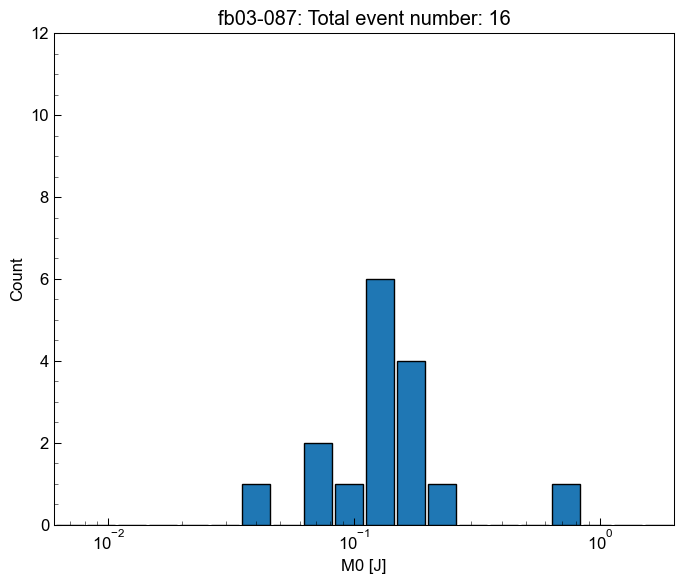

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
bins = np.logspace(np.log10(0.006), np.log10(2.0), 21) 

# bins=10

ax.hist(df_bestparam["M0_best"], bins=bins, rwidth=0.9, ec='k')

ax.set_xscale('log')
ax.set_xlabel("M0 [J]") 
ax.set_ylabel("Count") 
ax.set_xlim([0.006, 2.0])
ax.set_ylim([0, 12]) 
ax.set_title(f"fb03-{expr_id:03d}: Total event number: {len(event_ids)}")

fig.tight_layout()
plt.savefig(figdir + f"/hist_eventmagnitude_fb03-{expr_id:03d}.jpg", dpi=80, bbox_inches="tight")